# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


## Recordatorio

En esta actividad conviene apoyarse en lo que ya veníamos haciendo: primero mirar la imagen, después leer canales e histogramas, recién ahí probar umbrales, y al final comparar resultados para justificar una decisión.


In [6]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


# Carga una imagen desde disco con OpenCV y la convierte de BGR a RGB.
# Esto permite verla correctamente con matplotlib y trabajar con los canales en el orden habitual.
def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


# Muestra la imagen original junto con sus tres canales para comparar
# qué zonas aparecen más claras en rojo, verde y azul.
def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


# Grafica los histogramas de los tres canales para ver cómo se distribuyen
# las intensidades y elegir umbrales con más criterio.
def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Genera una máscara lógica a partir de rangos mínimos y máximos para cada canal.
# La máscara queda en blanco donde se cumple la condición y en negro donde no.
def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [7]:
# Estas son las imágenes de apoyo que puede usar la actividad.
# Si no están en la carpeta, se descargan automáticamente.
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

# Si está disponible la imagen preprocesada del cuaderno anterior,
# se informa para poder usarla como entrada principal.
if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


También está disponible: imagen_preprocesada.png
Imágenes listas para la actividad.


## 1. Elegir la imagen y definir el color objetivo

Si está disponible `imagen_preprocesada.png`, se usa como imagen principal. La idea es trabajar sobre la misma imagen recuperada en el cuaderno anterior para mantener continuidad entre actividades.


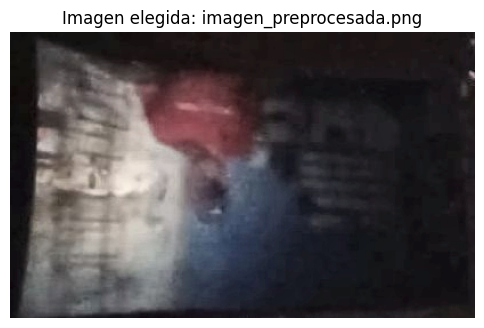

Color objetivo: zonas rojizas o calidas mas visibles de la imagen
Forma de la imagen: (251, 408, 3)
Tipo de dato: uint8


In [8]:
# Este bloque selecciona la imagen de trabajo, la carga en RGB y la muestra como referencia inicial.
# Se prioriza imagen_preprocesada.png porque es la versión mejorada en la actividad anterior.
if Path("imagen_preprocesada.png").exists():
    nombre_imagen = "imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # o "frutos_rojos.png"

imagen_rgb = cargar_rgb(nombre_imagen)

# En esta imagen conviene trabajar con tonos rojizos o calidos,
# porque son las zonas que mejor se distinguen dentro de una escena oscura.
color_objetivo = "zonas rojizas o calidas mas visibles de la imagen"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)
print("Forma de la imagen:", imagen_rgb.shape)
print("Tipo de dato:", imagen_rgb.dtype)


Se eligió trabajar con `imagen_preprocesada.png` porque permite continuar el proceso iniciado en el cuaderno de recuperación. El color objetivo son las zonas rojizas o cálidas, ya que aparecen con más presencia visual que otras regiones y ofrecen un punto de partida razonable para segmentar por RGB.


## 2. Separar canales y mirar histogramas

Antes de elegir umbrales conviene revisar qué aporta cada canal. Esa lectura previa evita elegir valores al azar y ayuda a justificar por qué una máscara funciona mejor que otra.


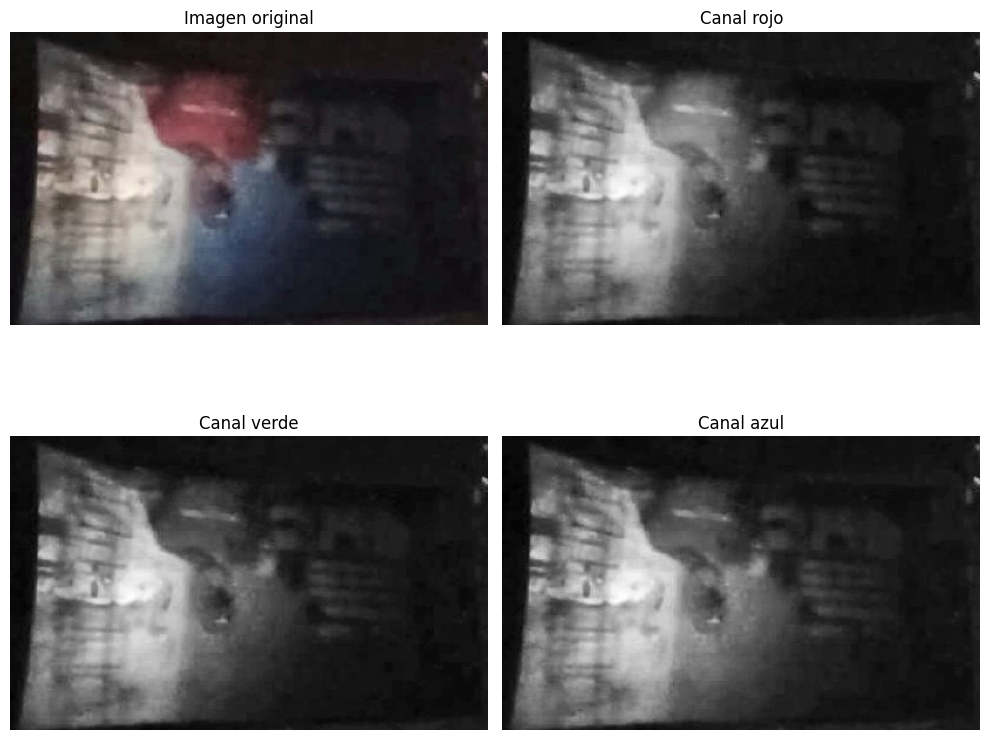

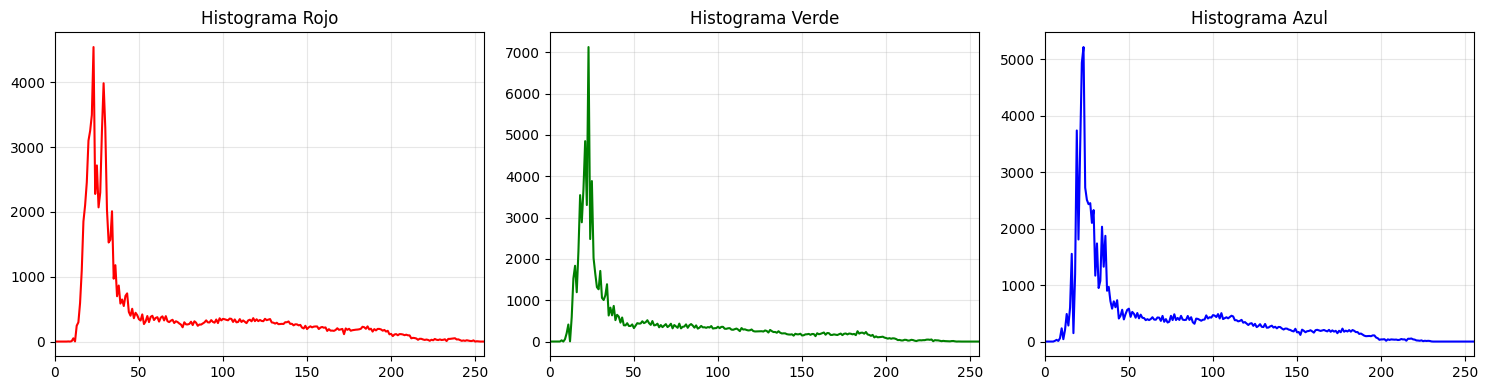

In [9]:
# Mostrar la imagen y sus tres canales por separado para comparar qué información aporta cada uno.
mostrar_canales(imagen_rgb)

# Graficar los histogramas de rojo, verde y azul para analizar cómo se distribuyen
# las intensidades y elegir umbrales con más criterio.
mostrar_histogramas(imagen_rgb)


El canal rojo es la pista principal, porque las zonas cálidas se ven más claras allí que en los otros canales. Los canales verde y azul también ayudan, pero sobre todo como filtro: permiten descartar partes del fondo oscuro o regiones donde el color objetivo no domina. Por eso la estrategia más razonable es pedir rojo relativamente alto y mantener verde y azul en rangos más acotados.


## 3. Primera estrategia de segmentación

La primera prueba usa un rango relativamente amplio. La idea es recuperar la mayor parte de las zonas cálidas, aunque todavía se cuele algo de fondo.


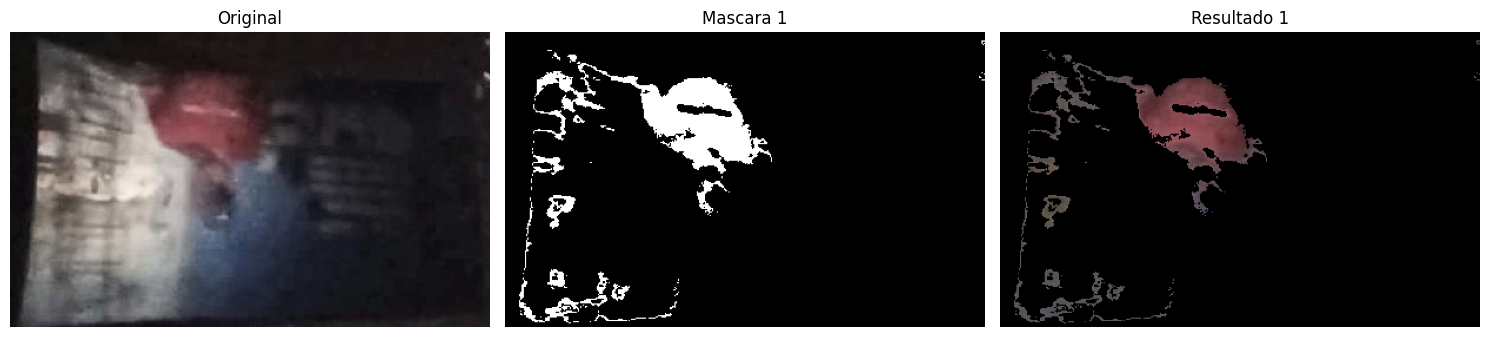

In [10]:
# Este bloque define una primera segmentacion con umbrales amplios.
# Se busca captar la mayor parte de las zonas rojizas sin exigir un rojo extremo.
r_min, r_max = 80, 210
g_min, g_max = 0, 95
b_min, b_max = 0, 95

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Mascara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()


Qué muestra esta primera prueba: la máscara recupera una región bastante amplia de tonos rojizos y cálidos. Eso es útil porque no deja afuera tanta información, pero también tiene una desventaja: todavía pueden aparecer algunos píxeles del fondo o de zonas oscuras con colores parecidos. En otras palabras, funciona como punto de partida, pero todavía no como resultado final.


## 4. Segunda estrategia y comparación

Ahora conviene ajustar los umbrales para volver la segmentación más estricta. La idea es reducir el ruido visual y conservar mejor las zonas principales del color buscado.


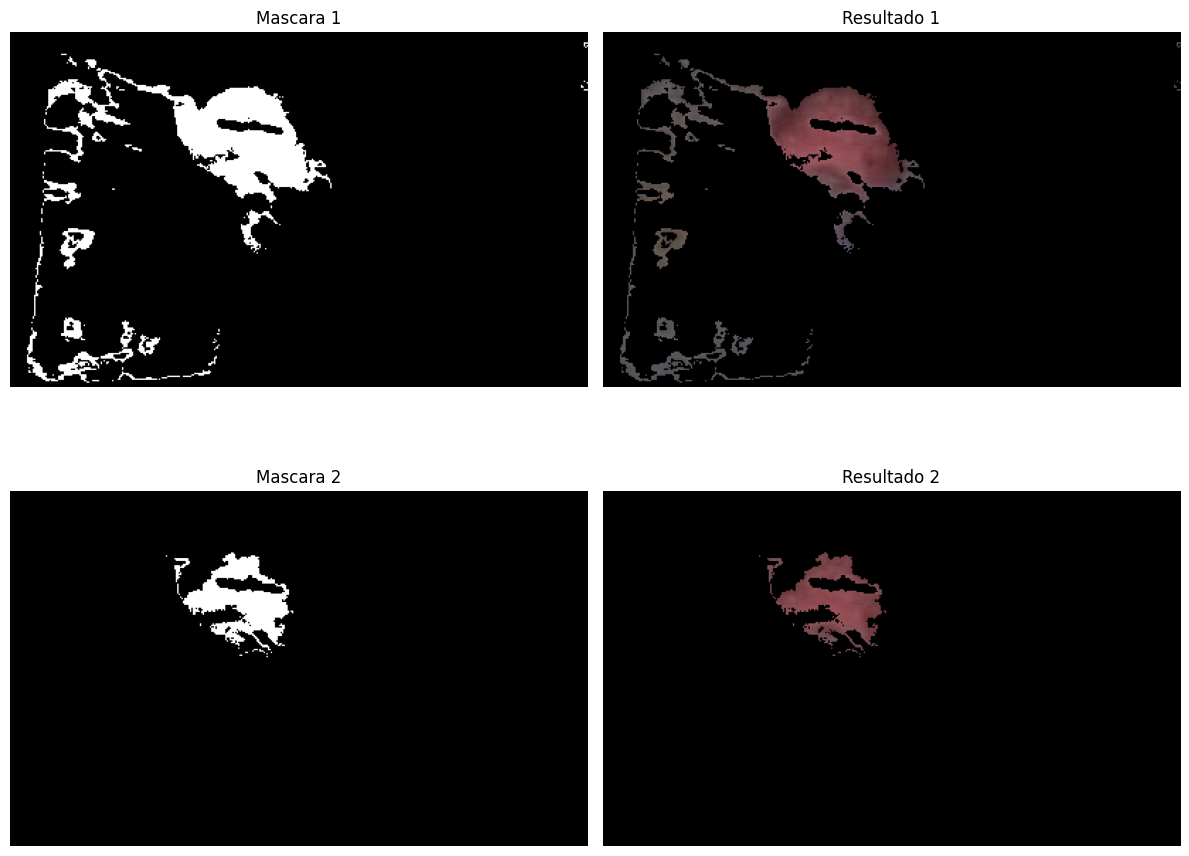

In [11]:
# Esta segunda estrategia exige un rojo mas alto y mantiene mas controlados
# los canales verde y azul para filtrar mejor el fondo.
r_min_2, r_max_2 = 110, 220
g_min_2, g_max_2 = 0, 90
b_min_2, b_max_2 = 0, 90

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Mascara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Mascara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


Comparación entre ambas estrategias: la primera recupera más superficie, pero deja pasar más píxeles del fondo. La segunda selecciona menos, aunque conserva mejor las zonas rojizas principales y produce una máscara más limpia. Para esta actividad conviene conservar la segunda estrategia, porque ofrece una separación más clara del color objetivo aunque pierda algunos bordes débiles.


## 5. Cierre escrito

1. ¿Qué color intentaste segmentar?
   Intenté segmentar las zonas rojizas o cálidas que quedaron más visibles en `imagen_preprocesada.png`.

2. ¿Qué canales te dieron la pista más útil?
   El canal rojo fue la pista principal, porque en esas regiones aparece más intenso que los otros. Los canales verde y azul ayudaron a descartar fondo y zonas menos cálidas.

3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
   En la primera estrategia usé un rango más amplio para no perder información. En la segunda aumenté el mínimo del rojo y mantuve más controlados verde y azul, para volver la máscara más estricta y limpiar mejor el resultado.

4. ¿Qué limitaciones encontraste en este método?
   La segmentación por umbrales RGB depende mucho de la iluminación. Como la imagen sigue siendo oscura y con poco detalle, algunos píxeles del fondo pueden parecerse al color objetivo y algunas zonas útiles pueden quedar afuera.

5. ¿Si tuvieras más tiempo, qué mejorarías?
   Probaría segmentar también en HSV o LAB, ajustaría la imagen con más preprocesamiento local y sumaría operaciones morfológicas para limpiar la máscara final.

### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
